# Exploracion dinamica de `data/processed`

Este notebook detecta automaticamente los datasets presentes en `data/processed`, calcula recuentos y porcentajes, valida el formato basico de los `.npz` y muestra ejemplos por dataset. Si anades un dataset nuevo y sus `.npz` tienen `dataset`, `t1`, `t2` y `label`, aparecera sin editar el notebook.

## 1. Configuracion

In [1]:
from pathlib import Path
from collections import Counter, defaultdict
import json
import random

import numpy as np

try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError("Falta matplotlib. Ejecuta `%pip install matplotlib` y reinicia el kernel.") from exc

cwd = Path.cwd().resolve()
REPO_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
PROCESSED_DIR = REPO_ROOT / "data" / "processed"
SUMMARY_FILE = PROCESSED_DIR / "preprocessing_summary.json"

RANDOM_SEED = 42
N_EXAMPLES_PER_DATASET = 5
AXIS = 2  # 0=sagital, 1=coronal, 2=axial

random.seed(RANDOM_SEED)

print(f"Repo root    : {REPO_ROOT}")
print(f"Processed dir: {PROCESSED_DIR}")
assert PROCESSED_DIR.exists(), f"No existe {PROCESSED_DIR}"

Repo root    : C:\Trabajo Fin Grado\brain-mri-triage
Processed dir: C:\Trabajo Fin Grado\brain-mri-triage\data\processed


## 2. Escaneo dinamico

In [2]:
def scalar_to_python(value):
    if isinstance(value, np.ndarray):
        value = value.item()
    if isinstance(value, bytes):
        return value.decode("utf-8")
    return value


def infer_dataset_from_path(path, npz_keys=None):
    path = Path(path)
    name = path.stem.lower()
    parent = path.parent.name.lower()

    if name.startswith("brats"):
        return "brats"
    if name.startswith("upenn"):
        return "upenn"
    if name.startswith("ixi"):
        return "ixi"
    if parent not in {"positives", "negatives"}:
        return parent
    return "unknown"


def infer_label_from_folder(path):
    parent = Path(path).parent.name.lower()
    if parent == "positives":
        return 1
    if parent == "negatives":
        return 0
    return None


def inspect_npz_record(path):
    path = Path(path)
    record = {
        "path": path,
        "relative_path": path.relative_to(PROCESSED_DIR).as_posix(),
        "folder": path.parent.name,
        "dataset": infer_dataset_from_path(path),
        "label": infer_label_from_folder(path),
        "keys": [],
        "t1_shape": None,
        "t2_shape": None,
        "t1_dtype": None,
        "t2_dtype": None,
        "issues": [],
    }

    try:
        with np.load(path) as sample:
            keys = list(sample.files)
            record["keys"] = keys

            if "dataset" in keys:
                record["dataset"] = str(scalar_to_python(sample["dataset"])).lower()
            if "label" in keys:
                record["label"] = int(scalar_to_python(sample["label"]))

            missing = {"t1", "t2", "label"} - set(keys)
            if missing:
                record["issues"].append(f"faltan claves: {sorted(missing)}")

            if "t1" in keys:
                t1 = sample["t1"]
                record["t1_shape"] = tuple(t1.shape)
                record["t1_dtype"] = str(t1.dtype)
                if t1.ndim != 3:
                    record["issues"].append(f"t1 no es 3D: {t1.shape}")
                if not np.isfinite(t1).all():
                    record["issues"].append("t1 contiene NaN o Inf")

            if "t2" in keys:
                t2 = sample["t2"]
                record["t2_shape"] = tuple(t2.shape)
                record["t2_dtype"] = str(t2.dtype)
                if t2.ndim != 3:
                    record["issues"].append(f"t2 no es 3D: {t2.shape}")
                if not np.isfinite(t2).all():
                    record["issues"].append("t2 contiene NaN o Inf")

            if record["t1_shape"] and record["t2_shape"] and record["t1_shape"] != record["t2_shape"]:
                record["issues"].append(f"T1/T2 shapes distintas: {record['t1_shape']} vs {record['t2_shape']}")

            folder_label = infer_label_from_folder(path)
            if folder_label is not None and record["label"] != folder_label:
                record["issues"].append(f"label={record['label']} no coincide con carpeta {record['folder']}")

    except Exception as exc:
        record["issues"].append(f"error al cargar: {exc}")

    return record


npz_files = sorted(PROCESSED_DIR.rglob("*.npz"))
records = [inspect_npz_record(path) for path in npz_files]

print(f"Archivos .npz encontrados: {len(records)}")

Archivos .npz encontrados: 2267


## 3. Recuento y porcentajes

In [3]:
def pct(part, total):
    return 100 * part / total if total else 0


total = len(records)
label_counts = Counter(record["label"] for record in records)
dataset_counts = Counter(record["dataset"] for record in records)

print("Resumen por clase")
for label, name in [(1, "positivos"), (0, "negativos"), (None, "desconocidos")]:
    count = label_counts.get(label, 0)
    print(f"  {name:12s}: {count:4d} ({pct(count, total):5.1f}%)")
print(f"  {'total':12s}: {total:4d} (100.0%)")

print("\nResumen por dataset")
print(f"{'dataset':14s} {'total':>6s} {'% total':>8s} {'pos':>6s} {'neg':>6s} {'carpetas'}")
for dataset, count in sorted(dataset_counts.items(), key=lambda item: (-item[1], item[0])):
    rows = [record for record in records if record["dataset"] == dataset]
    n_pos = sum(record["label"] == 1 for record in rows)
    n_neg = sum(record["label"] == 0 for record in rows)
    folders = sorted({record["folder"] for record in rows})
    print(f"{dataset:14s} {count:6d} {pct(count, total):7.1f}% {n_pos:6d} {n_neg:6d} {folders}")

if SUMMARY_FILE.exists():
    with open(SUMMARY_FILE, encoding="utf-8") as f:
        saved_summary = json.load(f)
    print("\nComparacion con preprocessing_summary.json")
    print(f"  total guardado     : {saved_summary.get('total')}")
    print(f"  positivos guardado : {saved_summary.get('positives')}")
    print(f"  negativos guardado : {saved_summary.get('negatives')}")

Resumen por clase
  positivos   : 1167 ( 51.5%)
  negativos   : 1100 ( 48.5%)
  desconocidos:    0 (  0.0%)
  total       : 2267 (100.0%)

Resumen por dataset
dataset         total  % total    pos    neg carpetas
upenn             587    25.9%    587      0 ['positives']
brats             580    25.6%    580      0 ['positives']
ixi               577    25.5%      0    577 ['negatives']
nki_rockland      523    23.1%      0    523 ['negatives']

Comparacion con preprocessing_summary.json
  total guardado     : 2267
  positivos guardado : 1167
  negativos guardado : 1100


## 4. Validacion rapida

In [4]:
issues = [record for record in records if record["issues"]]

print("Shapes por dataset")
for dataset in sorted(dataset_counts):
    rows = [record for record in records if record["dataset"] == dataset]
    t1_shapes = Counter(record["t1_shape"] for record in rows)
    t2_shapes = Counter(record["t2_shape"] for record in rows)
    labels = Counter(record["label"] for record in rows)
    print(f"\n{dataset}")
    print(f"  labels   : {dict(labels)}")
    print(f"  T1 shapes: {dict(t1_shapes)}")
    print(f"  T2 shapes: {dict(t2_shapes)}")

print(f"\nArchivos con problemas: {len(issues)}")
for record in issues[:20]:
    print(f"- {record['relative_path']}: {'; '.join(record['issues'])}")
if len(issues) > 20:
    print(f"... y {len(issues) - 20} mas")

Shapes por dataset

brats
  labels   : {1: 580}
  T1 shapes: {(192, 224, 192): 580}
  T2 shapes: {(192, 224, 192): 580}

ixi
  labels   : {0: 577}
  T1 shapes: {(192, 224, 192): 577}
  T2 shapes: {(192, 224, 192): 577}

nki_rockland
  labels   : {0: 523}
  T1 shapes: {(192, 224, 192): 523}
  T2 shapes: {(192, 224, 192): 523}

upenn
  labels   : {1: 587}
  T1 shapes: {(192, 224, 192): 587}
  T2 shapes: {(192, 224, 192): 587}

Archivos con problemas: 0


## 5. Funciones de visualizacion

In [5]:
display_cmap = plt.cm.gray.copy()
display_cmap.set_bad(color="black")


def foreground_values(img, eps=1e-6):
    values = img[np.isfinite(img)]
    if values.size == 0:
        return values
    foreground = values[np.abs(values) > eps]
    return foreground if foreground.size else values


def robust_window(img, low=1, high=99):
    values = foreground_values(img)
    if values.size == 0:
        return 0.0, 1.0
    lo, hi = np.percentile(values, [low, high])
    if np.isclose(lo, hi):
        lo, hi = float(np.min(values)), float(np.max(values))
    if np.isclose(lo, hi):
        hi = lo + 1.0
    return lo, hi


def masked_for_display(img, eps=1e-6):
    rotated = np.rot90(img)
    return np.ma.masked_where(np.abs(rotated) <= eps, rotated)


def best_slice_index(volume, axis=2, eps=1e-6):
    foreground = np.abs(volume) > eps
    if axis == 0:
        counts = foreground.sum(axis=(1, 2))
    elif axis == 1:
        counts = foreground.sum(axis=(0, 2))
    elif axis == 2:
        counts = foreground.sum(axis=(0, 1))
    else:
        raise ValueError("axis debe ser 0, 1 o 2")
    if counts.max() == 0:
        return volume.shape[axis] // 2
    return int(np.argmax(counts))


def get_slice(volume, axis=2, index=None):
    if index is None:
        index = best_slice_index(volume, axis=axis)
    if axis == 0:
        return volume[index, :, :], index
    if axis == 1:
        return volume[:, index, :], index
    if axis == 2:
        return volume[:, :, index], index
    raise ValueError("axis debe ser 0, 1 o 2")


def show_dataset_examples(dataset, n_examples=5, axis=2):
    rows = [record for record in records if record["dataset"] == dataset and not record["issues"]]
    if not rows:
        print(f"{dataset}: no hay muestras validas para visualizar")
        return

    sample_rows = random.sample(rows, k=min(n_examples, len(rows)))
    n = len(sample_rows)
    fig, axes = plt.subplots(n, 2, figsize=(8, max(3, 2.8 * n)))
    if n == 1:
        axes = np.array([axes])

    for row_idx, record in enumerate(sample_rows):
        with np.load(record["path"]) as sample:
            t1 = sample["t1"]
            t2 = sample["t2"]
            label = int(scalar_to_python(sample["label"]))

        combined = np.maximum(np.abs(t1), np.abs(t2))
        used_index = best_slice_index(combined, axis=axis)
        t1_slice, _ = get_slice(t1, axis=axis, index=used_index)
        t2_slice, _ = get_slice(t2, axis=axis, index=used_index)

        for col_idx, (img, modality) in enumerate([(t1_slice, "T1"), (t2_slice, "T2")]):
            ax = axes[row_idx, col_idx]
            vmin, vmax = robust_window(img)
            ax.imshow(masked_for_display(img), cmap=display_cmap, vmin=vmin, vmax=vmax)
            ax.set_title(f"{modality} | label={label} | slice={used_index} | {record['relative_path']}", fontsize=8)
            ax.axis("off")

    fig.suptitle(f"{dataset}: {n} ejemplos | axis={axis}", fontsize=13)
    plt.tight_layout()
    plt.show()


## 6. Visualizar 5 imagenes por dataset

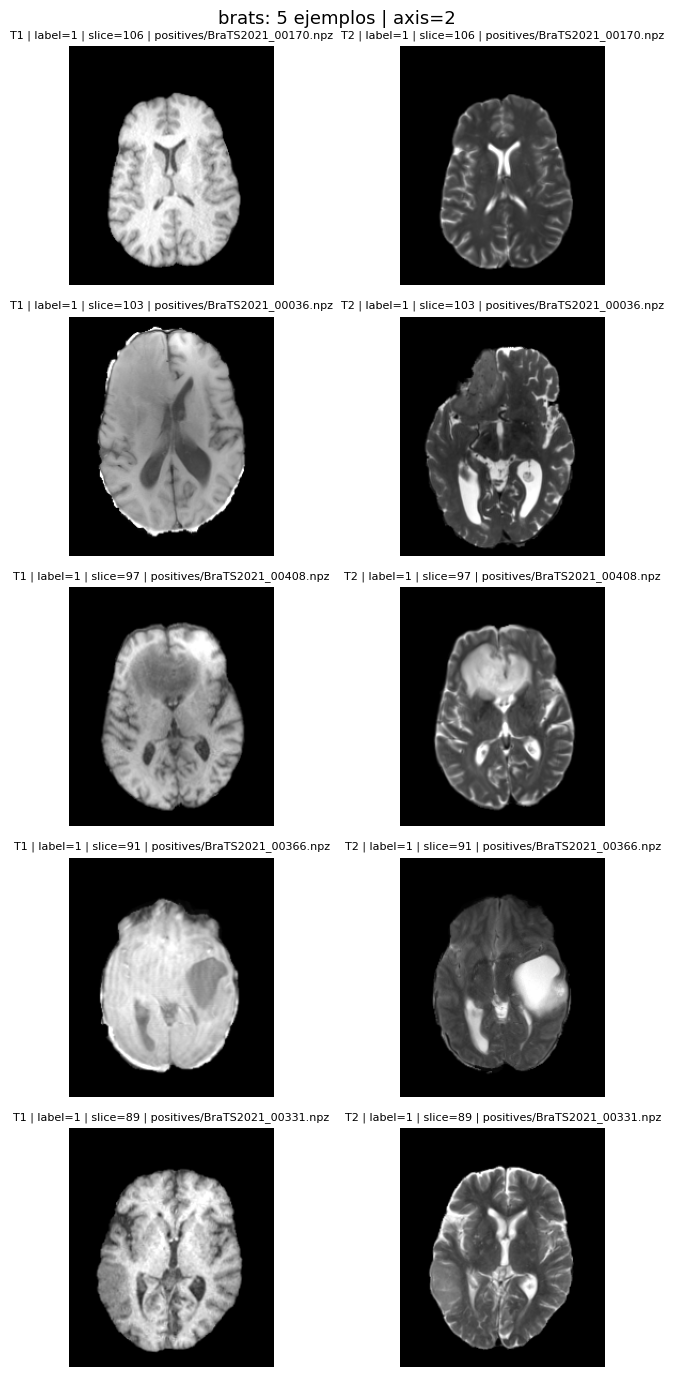

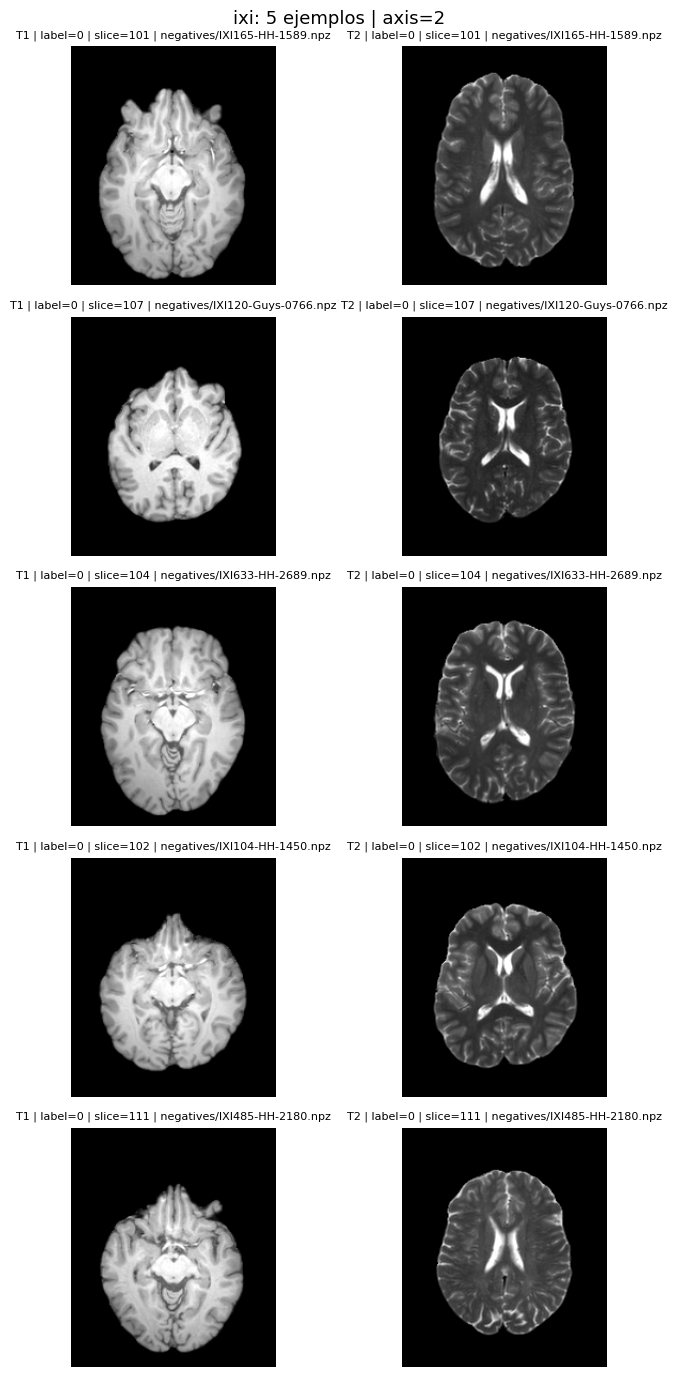

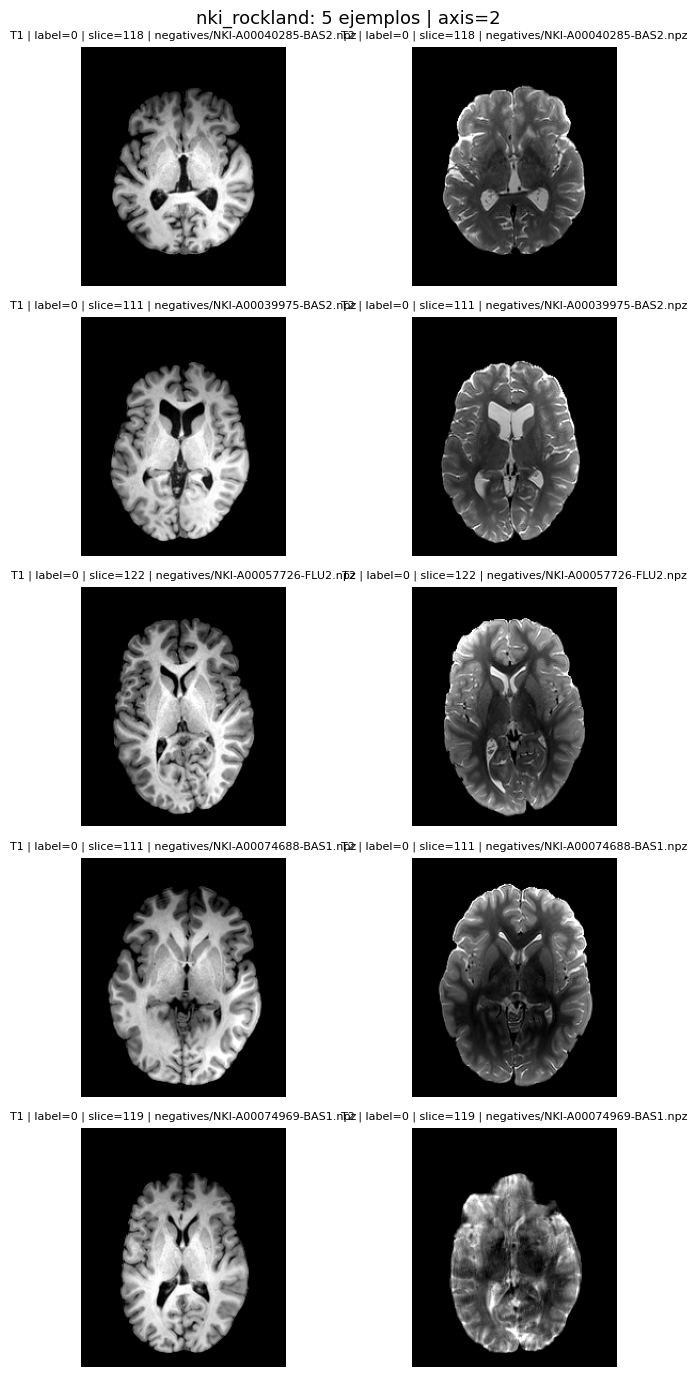

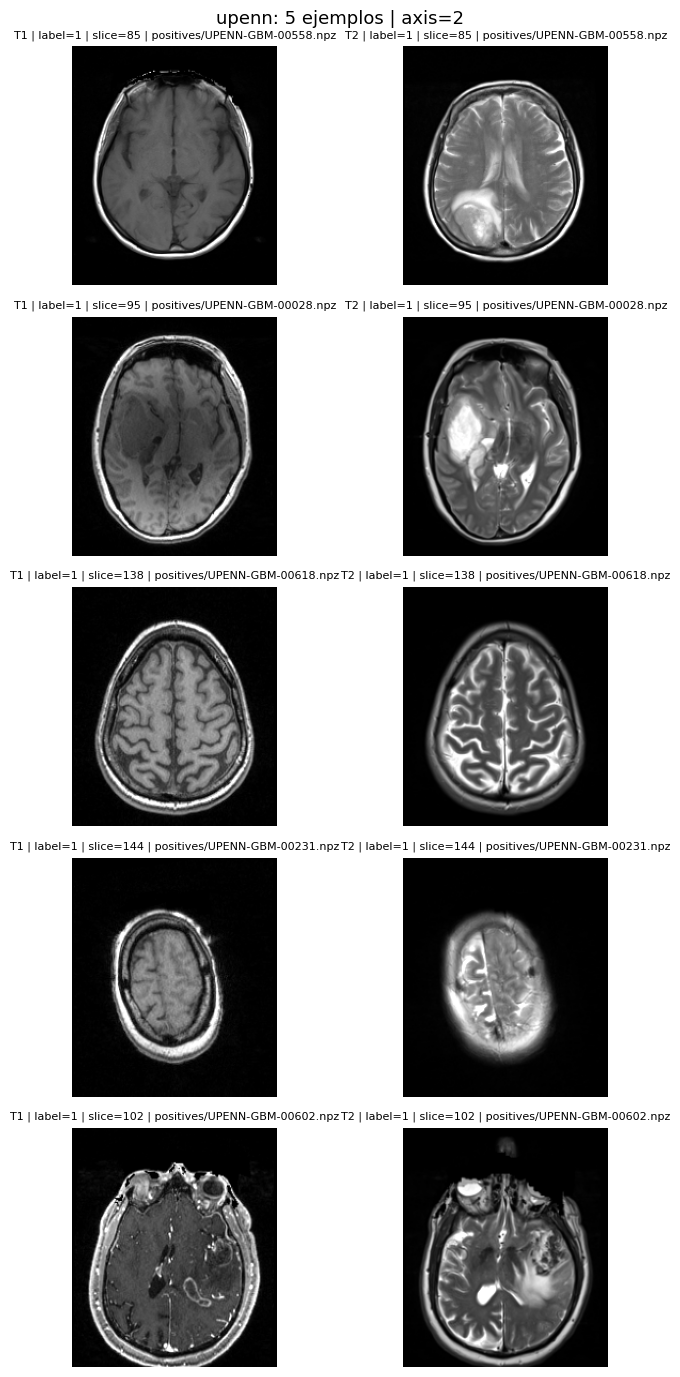

In [6]:
for dataset in sorted(dataset_counts):
    show_dataset_examples(dataset, n_examples=N_EXAMPLES_PER_DATASET, axis=AXIS)